## This notebook provides the methodology used in order to select relevant features for models training and comparison, analysis and observations of trained models.

You must read [eda.ipynb](eda.ipynb) and [tsne.ipynb](tsne.ipynb) before this one.


---

## Feature selection

### Importing the dataset

In [1]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
api = KaggleApi()
api.authenticate()

if not os.path.exists("../datasets/Students Social Media Addiction.csv"):
    api.dataset_download_files(
        "zahranusratt/student-social-media-addiction-analysis-dataset",
        path="../datasets",
        unzip=True
    )
else:
    print("dataset already on local files")

csv_file = os.path.join("../datasets","Students Social Media Addiction.csv")
whole_df = pd.read_csv(csv_file)

print("dataset ready to use")

dataset already on local files
dataset ready to use


In [2]:
stats_summary = whole_df.describe()
print(stats_summary)

print('\n', '*'*50)
print("feature number (except Student_ID):", len(whole_df.columns) - 1)
print(whole_df.columns)


       Student_ID         Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  705.000000  705.000000             705.000000             705.000000   
mean   353.000000   20.659574               4.918723               6.868936   
std    203.660256    1.399217               1.257395               1.126848   
min      1.000000   18.000000               1.500000               3.800000   
25%    177.000000   19.000000               4.100000               6.000000   
50%    353.000000   21.000000               4.800000               6.900000   
75%    529.000000   22.000000               5.800000               7.700000   
max    705.000000   24.000000               8.500000               9.600000   

       Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  
count           705.000000                   705.000000      705.000000  
mean              6.226950                     2.849645        6.436879  
std               1.105055                     0.957968        1.5

### Main objective & methodology

Use regression or classification to get an **assertive Addicted_Score**. This will be achieved by select features that are relevant to provide an accurate Addiction score based on the data provided by the dataset.

Insights from previous notebooks will be used to recover insights gathered until now, alongside creating new ones to filter even more what will be considered relevant.

e.g.:
- Correlation table
- High-dimensional data simplified with t-SNE
- Deeper analysis based on Addicted_Score

Also, new feature selection techniques will be applied.
e.g.:
- Variable Ranking
- Statistical Tests (Chi-square, ANOVA F-tests)
- Data engineering 
- Wrappers
- Dimensionality reduction (PCA)

### Splitting the dataset

In [3]:
# TODO SPLIT THE DATASET 80% TRAINING 20% TEST
# PEFORM FEATURE SELECTION
    # ok partially
# TRAIN THE MODELS
# VALIDATE

# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


### Numerical feature selection

#### Variable Ranking

In [4]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
import pandas as pd

# preparing the test: X = predictors, y = target (Addicted_Score)
df_numeric = whole_df.select_dtypes(['number']).drop(columns='Student_ID')
X = df_numeric.drop(columns='Addicted_Score')
y = df_numeric['Addicted_Score']
print(X.info(), y.info())
df_numeric.head()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          705 non-null    int64  
 1   Avg_Daily_Usage_Hours        705 non-null    float64
 2   Sleep_Hours_Per_Night        705 non-null    float64
 3   Mental_Health_Score          705 non-null    int64  
 4   Conflicts_Over_Social_Media  705 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 27.7 KB
<class 'pandas.Series'>
RangeIndex: 705 entries, 0 to 704
Series name: Addicted_Score
Non-Null Count  Dtype
--------------  -----
705 non-null    int64
dtypes: int64(1)
memory usage: 5.6 KB
None None


,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
0,19,5.2,6.5,6,3,8
1,22,2.1,7.5,8,0,3
2,20,6.0,5.0,5,4,9
3,18,3.0,7.0,7,1,4
4,21,4.5,6.0,6,2,7


In [5]:
reg = SelectKBest(mutual_info_regression, k=4).fit(X,y)
# printing the results sorted by score
scores = reg.scores_
feature_scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": scores
}).sort_values(by="Score", ascending=False)
print(feature_scores)

selected_features = X.columns[reg.get_support()]
select_k_best_filtered_features_df = X[selected_features]
print("\nSelected features:", selected_features.tolist())

                       Feature     Score
3          Mental_Health_Score  1.063637
4  Conflicts_Over_Social_Media  1.050487
1        Avg_Daily_Usage_Hours  0.619322
2        Sleep_Hours_Per_Night  0.514793
0                          Age  0.102485

Selected features: ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Conflicts_Over_Social_Media']


Based on variable ranking, the four most important features are:
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

While compared with **Addicted_Score** as the target.

#### Correlation-based ranking

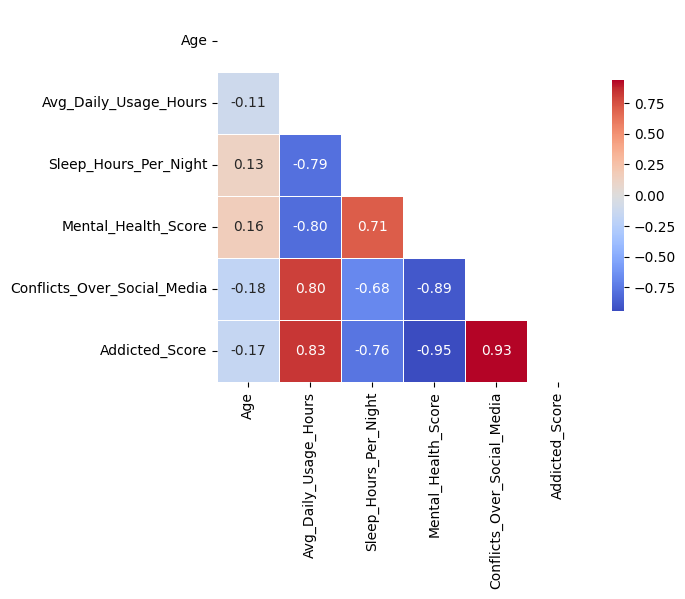

In [6]:
corr_matrix = df_numeric.corr()

plt.figure(figsize=(6, 6))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .5})
plt.show()

Similarly, it's possible to see a corroboration of these values gathered from the SelectKBest's regression.

The correlation are ranked as (in absolute values):
1. Mental_Health_Score
2. Conflicts_Over_Social_Media
3. Avg_Daily_Usage_Hours
4. Sleep_Hours_Per_Night

In [7]:
import pandas as pd
from scipy.stats import spearmanr

# multual info and correlation scores sorted by column
mi_scores = pd.Series(reg.scores_, index=X.columns)
corr_scores = X.corrwith(y).abs()

# comparison
df_compare = pd.DataFrame({
    "mutual_info": mi_scores,
    "correlation": corr_scores
}).loc[X.columns]   
print(df_compare)

# spearman score
spearman_corr, _ = spearmanr(df_compare["mutual_info"], df_compare["correlation"])
print("Spearman:", spearman_corr)


                             mutual_info  correlation
Age                             0.102485     0.166396
Avg_Daily_Usage_Hours           0.619322     0.832000
Sleep_Hours_Per_Night           0.514793     0.764858
Mental_Health_Score             1.063637     0.945051
Conflicts_Over_Social_Media     1.050487     0.933586
Spearman: 0.9999999999999999


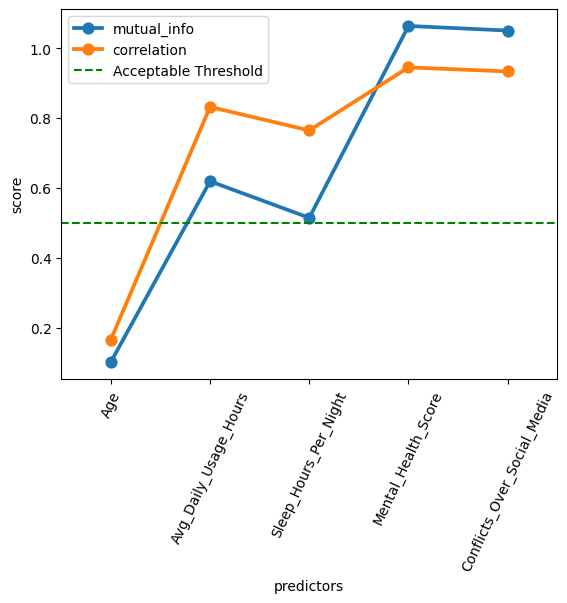

In [8]:
ax0 = sns.pointplot(df_compare['mutual_info'], label='mutual_info')
ax1 = sns.pointplot(df_compare['correlation'], label='correlation')
plt.xticks(rotation=65)
plt.axhline(y=0.5, color='green', linestyle='--', label='Acceptable Threshold')
plt.ylabel("score")
plt.xlabel("predictors")
plt.legend()


[Spearmanr's](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) compares two datasets and measures the monotonicity of the relationship between two datasets. The 0.9+ result cross-validate this corroboration.

### Categorical feature selection [WIP]

In [9]:
from scipy.stats import chi2_contingency

categorical_df = whole_df.select_dtypes(exclude='number')
categorical_df.info()

for column in categorical_df.columns.to_list():
    target = 'Affects_Academic_Performance'
    if column != target:
        chi_res = chi2_contingency(pd.crosstab(categorical_df['Affects_Academic_Performance'], categorical_df[column]))
        print('Testing Affects_Academic_Performance vs. *{}* \np-value: {}\n'.format(column ,chi_res[1]))


<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Gender                        705 non-null    str  
 1   Academic_Level                705 non-null    str  
 2   Country                       705 non-null    str  
 3   Most_Used_Platform            705 non-null    str  
 4   Affects_Academic_Performance  705 non-null    str  
 5   Relationship_Status           705 non-null    str  
dtypes: str(6)
memory usage: 33.2 KB
Testing Affects_Academic_Performance vs. *Gender* 
p-value: 0.5631338912008489

Testing Affects_Academic_Performance vs. *Academic_Level* 
p-value: 0.004533049861948384

Testing Affects_Academic_Performance vs. *Country* 
p-value: 2.4912206997876616e-49

Testing Affects_Academic_Performance vs. *Most_Used_Platform* 
p-value: 1.9173448996421343e-49

Testing Affects_Academic_Performance vs. *Relationship_Status* 

## Early model training and predictions

This section presents how different models behave while given selected or not features, and also how dataset limitations affect the training results and prediction.

Machine learning algorithms used:
- XGBoost
- LightGBM
- Random Forest
- SVM Support Vector Machines

### Training models using XGBoost

Using this example in order to incorporate numerical and categorical data for training:
[XGBoost's Native Support for Categorical Features](https://xgboosting.com/xgboosts-native-support-for-categorical-features/).

#### Without feature selection

This is the first experiment:
- Loading the dataset
- Handling categorical columns
- Instantiating a label enconder
- Defining predictors and target features
- Training the model
- Generating new data for prediction
- Making prediction
- Decoding the label to get the prediction's value

The generated data is a random csv line, copied without **Student_ID** and **Addicted_Score** features. Both are highlited in <font color="red">red</font>.

| <font color="red">~~3~~</font>| 20 | Female | Undergraduate | USA | 6.0 | TikTok | Yes | 5.0 | 5 | Complicated | 4 | <font color="red">~~9~~</font> |
|---|---|---|---|---|---|---|---|---|---|---|---|---|

The goal here is to assert if existent data would output the correct target value, which it did successfully.

In [10]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# Load data into a DataFrame
data = whole_df.drop(columns='Student_ID')

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

# Initialize and train the model
model = XGBClassifier(enable_categorical=True)
model.fit(X, y)

# Using a record from the dataset to see early results
new_data = pd.DataFrame(
    [{
        'Age': 20,
        'Gender': 'Female',
        'Academic_Level': 'Undergraduate',
        'Country': 'USA',
        'Avg_Daily_Usage_Hours': 6.0,
        'Most_Used_Platform': 'TikTok',
        'Affects_Academic_Performance': 'Yes',
        'Sleep_Hours_Per_Night': 5.0,
        'Mental_Health_Score': 5,
        'Relationship_Status': 'Complicated',
        'Conflicts_Over_Social_Media': 4
    }]
)

# Convert categorical columns to 'category' data type
for col in categorical_columns:
    new_data[col] = new_data[col].astype('category')

# Make predictions
predictions = model.predict(new_data)
print("encoded label:", predictions)

predicted_label = le.inverse_transform(predictions)
print("after encoder label transformation:", predicted_label)

encoded label: [7]
after encoder label transformation: [9]


In [11]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)
model = XGBClassifier(enable_categorical=True)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

train_pred = model.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9574468085106383
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      1.00      0.97        15
           2       0.96      1.00      0.98        22
           3       1.00      0.89      0.94         9
           4       0.93      0.98      0.96        44
           5       0.97      0.91      0.94        35
           6       1.00      1.00      1.00        13

    accuracy                           0.96       141
   macro avg       0.97      0.92      0.94       141
weighted avg       0.96      0.96      0.96       141

Train accuracy: 1.0
Test accuracy: 0.9574468085106383


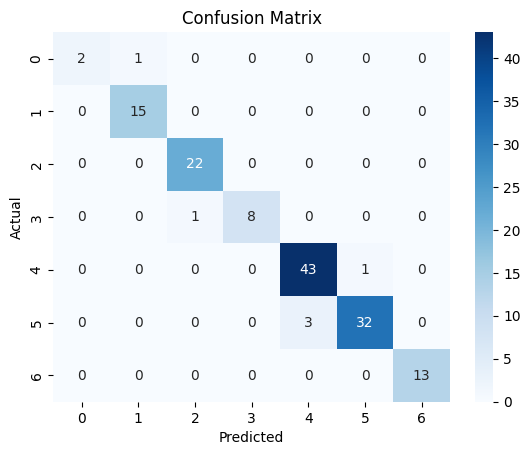

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

In [13]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder


# Student_ID                    = user ids, no valid insights
# Age                           = least important feature according to correlation matrix, mutual informantion, spearmanr scores
# Mental_Health_Score           = too high score (MI and corr.), could be acting as proxy for evaluating the target
# Conflicts_Over_Social_Media   = too high score (MI and corr.), could be acting as proxy for evaluating the target

# Load data into a DataFrame
drop_cols = [
    'Student_ID',
    'Age', 
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media'
]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test set
    random_state=42,    # reproducibility
)
model = XGBClassifier(
    max_depth=3,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1.0,
    reg_lambda=2.0,
    min_child_weight=3,
    enable_categorical=True,
    random_state=42
)
model.fit(X_train, y_train)

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

train_pred = model.predict(X_train)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9148936170212766
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      1.00      0.97        15
           2       0.88      1.00      0.94        22
           3       0.86      0.67      0.75         9
           4       0.88      0.98      0.92        44
           5       0.97      0.83      0.89        35
           6       1.00      0.92      0.96        13

    accuracy                           0.91       141
   macro avg       0.93      0.87      0.89       141
weighted avg       0.92      0.91      0.91       141

Train accuracy: 0.9626998223801065
Test accuracy: 0.9148936170212766


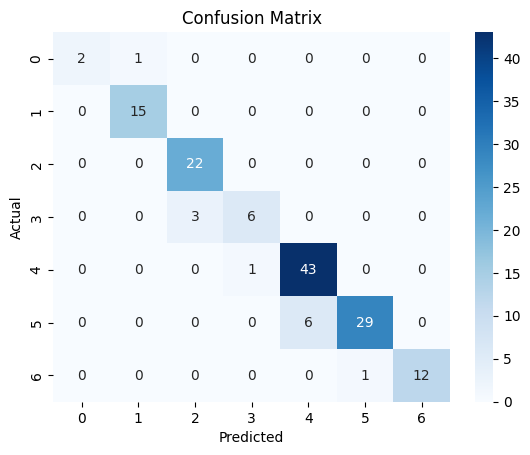

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Training models using LightGBM

#### Without feature selection

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score


import lightgbm as lgb

print("Loading data...")
drop_cols = ['Student_ID']
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test set
    random_state=42,    # reproducibility
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(3)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

print("Accuracy:", accuracy_score(y_test, y_pred))

Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006967 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 187
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 11
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.113772
[LightGBM] [Info] Start training from score -1.597081
[LightGBM] [Info] Start training from score -2.382036
[LightGBM] [Info] Start training from

In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

print("Loading data...")
drop_cols = [
            'Student_ID',
            'Age'
            ]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    categorical_feature=categorical_columns,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(3)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

from sklearn.metrics import classification_report
print(classification_report(y_test, gbm.predict(X_test)))


Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 179
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 10
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.113772
[LightGBM] [Info] Start training from score -1.597081
[LightGBM] [Info] Start training from score -2.382036
[LightGBM] [Info] Start training from score -1.227334
[LightGBM] [Info] Start training from score -1.

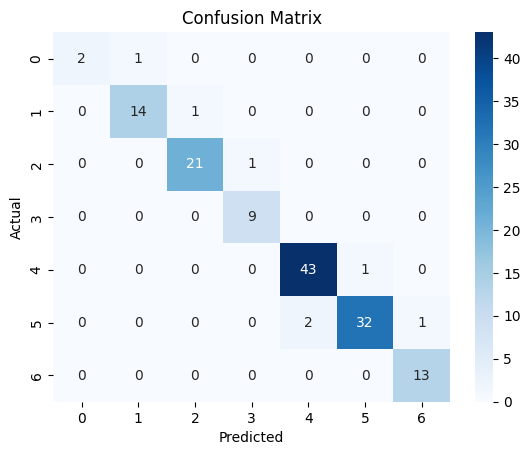

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

In [18]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
import lightgbm as lgb

print("Loading data...")
drop_cols = [
            'Student_ID',
            'Age', 
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media'
            ]
data = whole_df.drop(columns=drop_cols)
data = data[data['Addicted_Score'] != 2]

# Specify categorical columns
categorical_columns = whole_df.select_dtypes(exclude='number').columns.tolist()

# print(data.info())
# Convert categorical columns to 'category' data type
for col in categorical_columns:
    # print(col)
    data[col] = data[col].astype('category')

# Split into features and target
le = LabelEncoder()

X = data.drop(columns='Addicted_Score')
y = le.fit_transform(data.Addicted_Score)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Starting training...")
# train
gbm = lgb.LGBMClassifier(
    num_leaves=50,
    learning_rate=0.05,
    n_estimators=200,
    min_data_in_leaf=5,
    random_state=42
)
gbm.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(10)]
)

print("Starting predicting...")
# predict
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration_)
# eval
rmse_test = mean_squared_error(y_test, y_pred) ** 0.5
print(f"The RMSE of prediction is: {rmse_test}")

# feature importances
print(f"Feature importances: {list(gbm.feature_importances_)}")

from sklearn.metrics import classification_report
print(classification_report(y_test, gbm.predict(X_test)))


Loading data...
Starting training...
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000138 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 167
[LightGBM] [Info] Number of data points in the train set: 563, number of used features: 8
[LightGBM] [Warning] min_data_in_leaf is set=5, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=5
[LightGBM] [Info] Start training from score -3.768330
[LightGBM] [Info] Start training from score -2.113772
[LightGBM] [Info] Start training from score -1.597081
[LightGBM] [Info] Start training from score -2.382036
[LightGBM] [Info] Start training from score -1.227334
[LightGBM] [Info] Start training from score -1.6

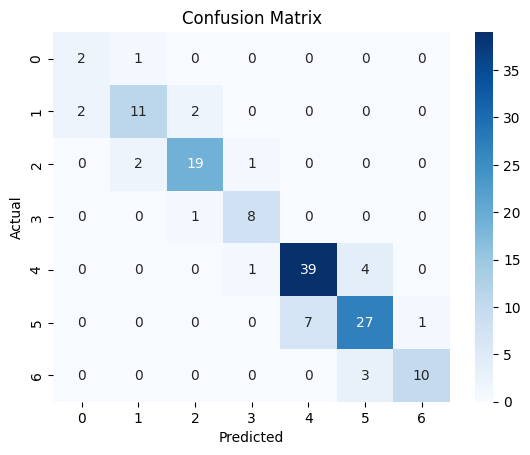

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Training models using Random Forest

#### Without feature selection

Accuracy: 0.950354609929078

Classification Report:
              precision    recall  f1-score   support

           3       1.00      0.67      0.80         3
           4       0.94      1.00      0.97        15
           5       0.96      1.00      0.98        22
           6       1.00      0.89      0.94         9
           7       0.93      0.98      0.96        44
           8       0.94      0.91      0.93        35
           9       1.00      0.92      0.96        13

    accuracy                           0.95       141
   macro avg       0.97      0.91      0.93       141
weighted avg       0.95      0.95      0.95       141



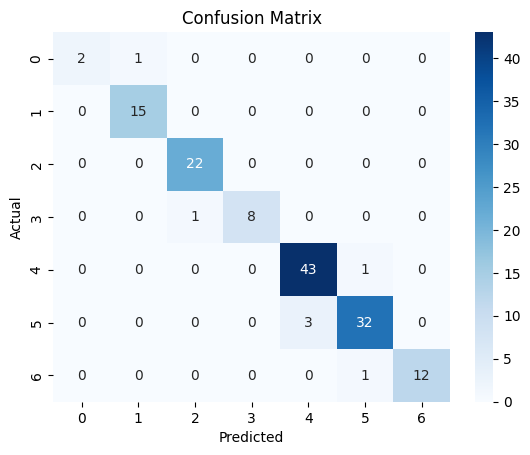

In [20]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = data.select_dtypes(exclude='number')
# convert categorical columns to 'category' data type
for col in categorical_columns.columns.tolist():
    # print(col)
    data[col] = data[col].astype('category')

# print(data.info())
# print(categorical_columns.info())

encoder = OneHotEncoder(sparse_output=False)
encoded_data_list = encoder.fit_transform(categorical_columns)
encoded_df = pd.DataFrame(
    encoded_data_list,
    columns=encoder.get_feature_names_out(categorical_columns.columns),
    index=data.index
)

merged_encoded_features = pd.concat([data.drop(columns=categorical_columns.columns), encoded_df], axis=1)
# print(merged_encoded_features.head())
# print(merged_encoded_features.columns.tolist())

# split into features and target

X = merged_encoded_features.drop(columns='Addicted_Score')
y = merged_encoded_features.Addicted_Score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

#### With feature selection

['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Addicted_Score', 'Gender_Female', 'Gender_Male', 'Academic_Level_Graduate', 'Academic_Level_High School', 'Academic_Level_Undergraduate', 'Country_Afghanistan', 'Country_Albania', 'Country_Andorra', 'Country_Argentina', 'Country_Armenia', 'Country_Australia', 'Country_Austria', 'Country_Azerbaijan', 'Country_Bahamas', 'Country_Bahrain', 'Country_Bangladesh', 'Country_Belarus', 'Country_Belgium', 'Country_Bhutan', 'Country_Bolivia', 'Country_Bosnia', 'Country_Brazil', 'Country_Bulgaria', 'Country_Canada', 'Country_Chile', 'Country_China', 'Country_Colombia', 'Country_Costa Rica', 'Country_Croatia', 'Country_Cyprus', 'Country_Czech Republic', 'Country_Denmark', 'Country_Ecuador', 'Country_Egypt', 'Country_Estonia', 'Country_Finland', 'Country_France', 'Country_Georgia', 'Country_Germany', 'Country_Ghana', 'Country_Greece', 'Country_Hong Kong', 'Country_Hungary', 'Country_Iceland', 'Country_India', 'Country_Indonesia', 'Country_Iraq', 'C

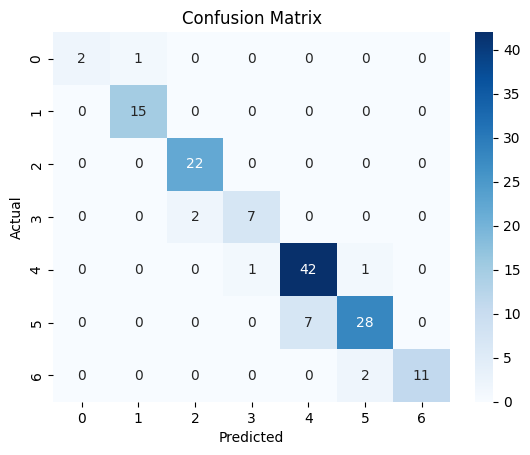

In [21]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

drop_cols = [
            'Age', 
            'Mental_Health_Score',
            'Conflicts_Over_Social_Media'
            ]
# load data into a DataFrame
data = whole_df.drop(columns='Student_ID')
# as this class only appear once, it wasn't possible to split test and training data correctly stratified, so I took it out
data = data[data['Addicted_Score'] != 2]

# specify categorical columns
categorical_columns = data.select_dtypes(exclude='number')
# convert categorical columns to 'category' data type
for col in categorical_columns.columns.tolist():
    # print(col)
    data[col] = data[col].astype('category')

# print(data.info())
# print(categorical_columns.info())

encoder = OneHotEncoder(sparse_output=False)
encoded_data_list = encoder.fit_transform(categorical_columns)
encoded_df = pd.DataFrame(
    encoded_data_list,
    columns=encoder.get_feature_names_out(categorical_columns.columns),
    index=data.index
)

merged_encoded_features = pd.concat([data.drop(columns=categorical_columns.columns), encoded_df], axis=1)
merged_encoded_features = merged_encoded_features.drop(columns=drop_cols)
print(merged_encoded_features.columns.tolist())

# split into features and target

X = merged_encoded_features.drop(columns='Addicted_Score')
y = merged_encoded_features.Addicted_Score

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Insights and Conclusion *(so far)*

- The predictions seem to be accurate from the training set perspective, reaching about (+-95% accuracy), although there are classes that cannot be asserted due to the lack of observations;
- The confusion matrices shows that there are **minor classes overlapping and adjacent mispredictions**;
- Manual feature selection seem to **worsen the accuracy and f1-score**, because tree-based algorithms already ignores unuseful features;
- Dropping some features with **both high mutual information and correlation scores did not break predictions**, which can be associated with **robustness** in the model;
    - so far, these numerical features:
        | feature | explanation |
        |---|---|
        | Student_ID | user ids, no valid for insights in any way |
        | Age | least important feature according to correlation matrix, mutual informantion, spearmanr scores |
        | Mental_Health_Score | too high score (MI and corr.), could be acting as proxy for evaluating the target |
        | Conflicts_Over_Social_Media | too high score (MI and corr.), could be acting as proxy for evaluating the target |